In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("iris-3.csv")

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [37]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [38]:
from sklearn.datasets import load_iris

iris = load_iris()


In [39]:
X = iris.data[:, :4]
y = iris.target

print(X.shape)
print(Y.shape)


(150, 4)
(150,)


In [40]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = Y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

In [43]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [44]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [45]:
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=0
)

In [46]:
bag_model.fit(X_train, Y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,0
,verbose,0


In [47]:
bag_pred = bag_model.predict(X_test)
print("Bagging Accuracy:", accuracy_score(Y_test, bag_pred))

Bagging Accuracy: 1.0


In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))

Random Forest Accuracy: 1.0


In [50]:
from sklearn.ensemble import AdaBoostClassifier

In [51]:
ada_model = AdaBoostClassifier(n_estimators=50, random_state=0)
ada_model.fit(X_train, Y_train)
ada_pred = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(Y_test, ada_pred))

AdaBoost Accuracy: 0.9666666666666667


In [52]:
from sklearn.ensemble import GradientBoostingClassifier

In [53]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=0)
gb_model.fit(X_train, Y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(Y_test, gb_pred))

Gradient Boosting Accuracy: 1.0


In [54]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [55]:
lr = LogisticRegression(max_iter=200)
rf = RandomForestClassifier(n_estimators=100, random_state=0)
svc = SVC(probability=True)

In [56]:
voting_model = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('svc', svc)],
    voting='soft'
)

In [57]:
voting_model.fit(X_train, Y_train)
voting_pred = voting_model.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(Y_test, voting_pred))

Voting Classifier Accuracy: 1.0


In [58]:
print("Bagging Accuracy:", accuracy_score(Y_test, bag_pred))
print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))
print("AdaBoost Accuracy:", accuracy_score(Y_test, ada_pred))
print("Gradient Boosting Accuracy:", accuracy_score(Y_test, gb_pred))
print("Voting Classifier Accuracy:", accuracy_score(Y_test, voting_pred))

Bagging Accuracy: 1.0
Random Forest Accuracy: 1.0
AdaBoost Accuracy: 0.9666666666666667
Gradient Boosting Accuracy: 1.0
Voting Classifier Accuracy: 1.0


In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

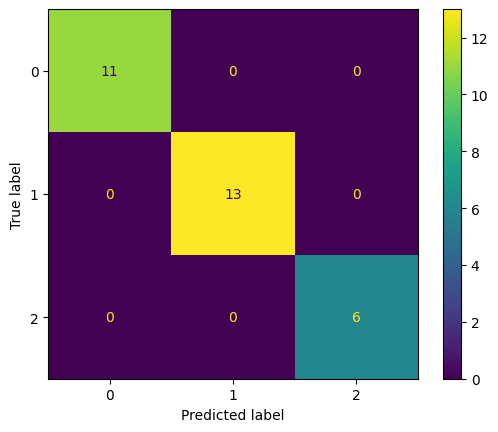

In [60]:
cm = confusion_matrix(Y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()